# Telco Customer Churn — Data Cleaning & Feature Engineering

**Project:** Customer Churn Analysis for a Telecom Company
**Notebook** Data Cleaning & Feature Engineering (Python)

## Objective

Before we can analyze *why* customers churn, we need a dataset we can trust.
This notebook takes the raw Telco Customer Churn dataset and turns it into
a clean, analysis-ready table: fixing data quality issues, standardizing
labels, and engineering a handful of new features that make the SQL and
Tableau work in the next two notebooks much more useful.

**What this notebook covers:**
1. Load the raw data and get a first read on its structure
2. Find and fix data quality issues (including a hidden one)
3. Clean up categorical labels
4. Engineer new features for churn analysis
5. Explore the cleaned data visually
6. Export the processed dataset for the SQL phase

**Business questions we're setting up to answer later:**
- What is our overall churn rate, and how much revenue does it represent?
- Which customer segments churn the most?
- Which contract, service, and payment combinations put customers at risk?


## 1. Setup

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Keep plots consistent and readable across the notebook
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)


In [21]:
# This notebook lives in `notebooks/`, so the project root is one level up.
# Keeping paths relative to PROJECT_ROOT (instead of hardcoding them) means
# this notebook runs the same way on any machine, including in CI.
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "telco_churn_cleaned.csv"
IMAGES_PATH = PROJECT_ROOT / "images"

# Make sure the output folders exist so saving never fails on a fresh clone
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
IMAGES_PATH.mkdir(parents=True, exist_ok=True)


## 2. Load & First Look

Every dataset starts with the same three questions: how big is it, what
does each column hold, and does anything look off right away.


In [22]:
df = pd.read_csv(RAW_DATA_PATH)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**First red flag:** `TotalCharges` is stored as `object` (text), even
though it clearly should be numeric. A numeric-looking column stored as
text almost always means there are hidden non-numeric characters — we'll
confirm and fix this in the next section.


## 3. Data Quality Check

A quick `isnull().sum()` on the raw data won't tell the whole story here,
because the missing values in `TotalCharges` aren't stored as `NaN` — they're
blank strings. This is a common real-world pattern: missing data doesn't
always look missing until you check the actual values, not just the type.


In [24]:
print("Explicit nulls in raw data:")
print(df.isnull().sum().sum(), "total")


Explicit nulls in raw data:
0 total


In [25]:
# errors="coerce" converts anything that isn't a valid number into NaN,
# which turns the hidden blanks into something we can actually detect.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

missing_charges = df["TotalCharges"].isnull().sum()
print(f"Hidden missing values found in TotalCharges: {missing_charges}")


Hidden missing values found in TotalCharges: 11


In [26]:
# Let's understand these rows before deciding what to do with them.
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


All of the missing `TotalCharges` values belong to customers with
**`tenure == 0`** — brand-new customers who haven't been billed yet. There's
no reasonable value to fill in here (a mean or median would misrepresent a
customer who's had zero months of billing), and none of them have churned,
so removing them costs us no churn signal. With only 11 rows out of 7,043,
this has no meaningful effect on the analysis.


In [27]:
rows_before = len(df)
df = df.drop(index=df[df["tenure"] == 0].index).reset_index(drop=True)

print(f"Removed {rows_before - len(df)} rows with zero tenure.")
print(f"Remaining missing values in the entire dataset: {df.isnull().sum().sum()}")


Removed 11 rows with zero tenure.
Remaining missing values in the entire dataset: 0


## 4. Clean Up Categorical Labels

Small consistency fixes now save confusion later, especially once this data
is feeding a Tableau dashboard where every label becomes a filter or legend.


In [28]:
# 0/1 is fine for modeling, but every other flag column in this dataset
# already uses Yes/No — matching that convention keeps things consistent.
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# customerID is a unique identifier, not an analytical feature — but it's
# still useful to keep as a stable row key for Tableau and SQL joins later.
df = df.rename(columns={"customerID": "CustomerID"})

df[["CustomerID", "SeniorCitizen"]].head()


,CustomerID,SeniorCitizen
0,7590-VHVEG,No
1,5575-GNVDE,No
2,3668-QPYBK,No
3,7795-CFOCW,No
4,9237-HQITU,No


## 5. Feature Engineering

Raw fields like `tenure` in months or `MonthlyCharges` as a raw dollar
amount aren't the easiest things to segment on or put in a dashboard filter.
Here we translate a few of them into features that map more directly to how
a business actually talks about its customers.

| New feature | Why it's useful |
|---|---|
| `TenureGroup` | Groups customers into year-based cohorts — much easier to read on a dashboard than raw months |
| `MonthlyChargesBucket` | Splits customers into spend tiers (quartile-based, so it reflects this dataset's actual distribution) |
| `TotalServices` | A simple "how attached is this customer to us" score — the more services someone has, the more switching costs them |
| `HasInternetService` | Quick flag for a service that turns out to matter a lot for churn |
| `AvgMonthlyCharges` | Actual average spend per month (`TotalCharges / tenure`), useful for customers who've had price changes over time |
| `IsNewCustomer` | Flags customers in their first 6 months — typically the highest-risk period for churn |


In [29]:
def tenure_to_group(tenure_months: int) -> str:
    """Bucket tenure in months into readable one-year cohorts."""
    year = (tenure_months - 1) // 12
    return f"{year}-{year + 1} years" if year < 5 else "5+ years"


df["TenureGroup"] = df["tenure"].apply(tenure_to_group)
df["TenureGroup"].value_counts().sort_index()


TenureGroup
0-1 years    2175
1-2 years    1024
2-3 years     832
3-4 years     762
4-5 years     832
5+ years     1407
Name: count, dtype: int64

In [30]:
# Quartile-based buckets so each tier reflects roughly a quarter of
# customers, rather than picking arbitrary dollar cutoffs.
df["MonthlyChargesBucket"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium", "High", "Premium"],
)
df["MonthlyChargesBucket"].value_counts().sort_index()


MonthlyChargesBucket
Low        1758
Medium     1761
High       1755
Premium    1758
Name: count, dtype: int64

In [31]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]


def count_active_services(row: pd.Series) -> int:
    """Count how many optional services a customer is subscribed to.

    Internet access itself counts as one service on top of the add-ons
    above, since it's the foundation the other services depend on.
    """
    active = sum(row[col] == "Yes" for col in service_columns)
    if row["InternetService"] != "No":
        active += 1
    return active


df["TotalServices"] = df.apply(count_active_services, axis=1)
df["HasInternetService"] = np.where(df["InternetService"] != "No", "Yes", "No")
df["AvgMonthlyCharges"] = (df["TotalCharges"] / df["tenure"]).round(2)
df["IsNewCustomer"] = np.where(df["tenure"] <= 6, "Yes", "No")

df[["TotalServices", "HasInternetService", "AvgMonthlyCharges", "IsNewCustomer"]].head()


,TotalServices,HasInternetService,AvgMonthlyCharges,IsNewCustomer
0,2,Yes,29.85,Yes
1,4,Yes,55.57,No
2,4,Yes,54.08,Yes
3,4,Yes,40.91,No
4,2,Yes,75.82,Yes


## 6. Exploratory Data Analysis

With clean data and a few new features in place, let's look at the shape
of churn in this dataset before moving into SQL for deeper segmentation.
Each chart below is saved to the `images/` folder for reuse in the README
and the final presentation.


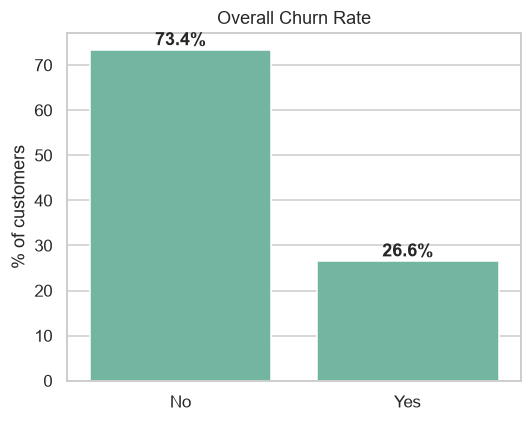

Overall churn rate: 26.6%


In [32]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=ax)
ax.set_title("Overall Churn Rate")
ax.set_ylabel("% of customers")
ax.set_xlabel("")
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(IMAGES_PATH / "01_overall_churn_rate.png")
plt.show()

print(f"Overall churn rate: {churn_counts['Yes']:.1f}%")


In [33]:
def churn_rate_by(column: str) -> pd.DataFrame:
    """Return the churn rate within each category of a given column.

    For example, churn_rate_by("Contract") answers: 'of all customers on
    a month-to-month contract, what % churned?' — not 'of all customers
    who churned, what % were on a month-to-month contract?'. The first
    question is what actually tells us which segments are risky; the
    second just describes the churned group and can be misleading when
    segment sizes differ a lot.
    """
    summary = (
        df.assign(is_churned=(df["Churn"] == "Yes"))
        .groupby(column)["is_churned"]
        .agg(churn_rate="mean", customers="count")
        .sort_values("churn_rate", ascending=False)
    )
    summary["churn_rate"] = (summary["churn_rate"] * 100).round(1)
    return summary


churn_rate_by("Contract")


,churn_rate,customers
Contract,,
Month-to-month,42.7,3875
One year,11.3,1472
Two year,2.8,1685


Month-to-month customers churn at roughly **15x the rate** of two-year
contract customers — by far the strongest single signal in this table.


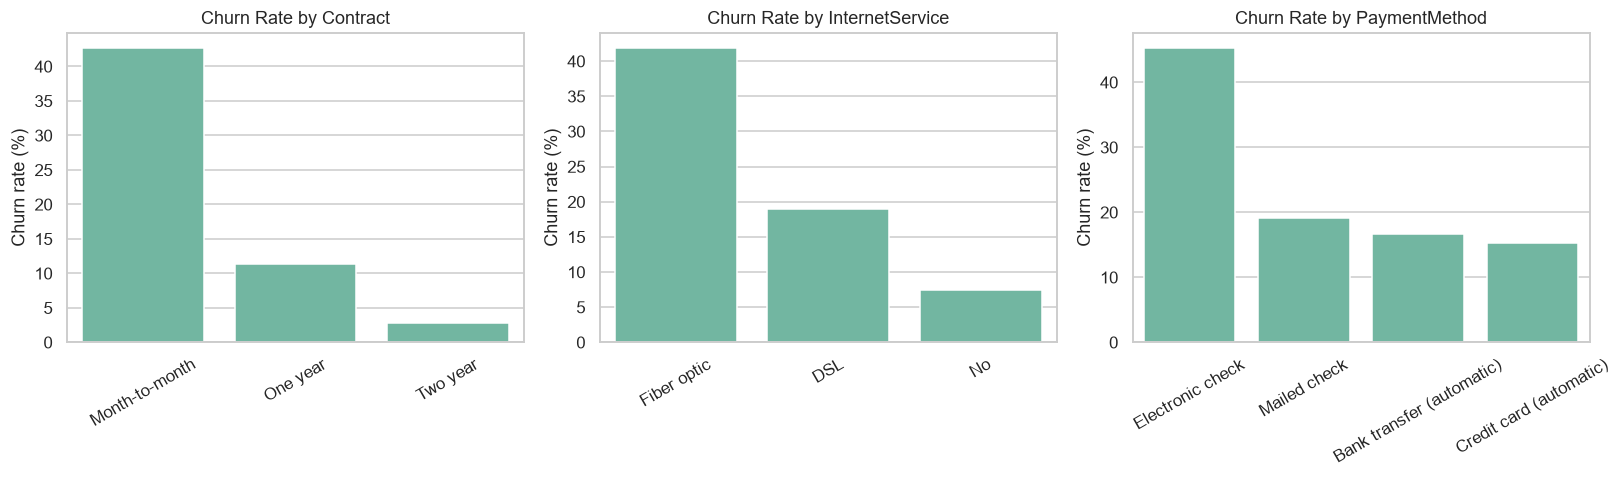

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, column in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    summary = churn_rate_by(column)
    sns.barplot(x=summary.index, y=summary["churn_rate"], ax=ax)
    ax.set_title(f"Churn Rate by {column}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(IMAGES_PATH / "02_churn_rate_by_segment.png")
plt.show()


Three segments already stand out as high-risk: **month-to-month contracts**,
**fiber optic internet**, and **electronic check** as a payment method. We'll
quantify exactly how much revenue is tied up in these segments once we move
into SQL.


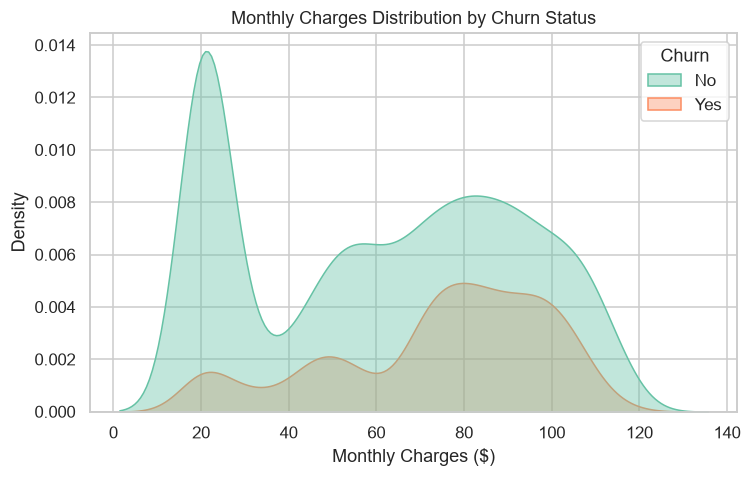

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.kdeplot(
    data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.4, ax=ax
)
ax.set_title("Monthly Charges Distribution by Churn Status")
ax.set_xlabel("Monthly Charges ($)")

plt.tight_layout()
plt.savefig(IMAGES_PATH / "03_monthly_charges_by_churn.png")
plt.show()


Customers who churn skew toward **higher monthly charges** — the distribution
for churned customers is shifted noticeably to the right of retained
customers, which lines up with the segment-level findings above.


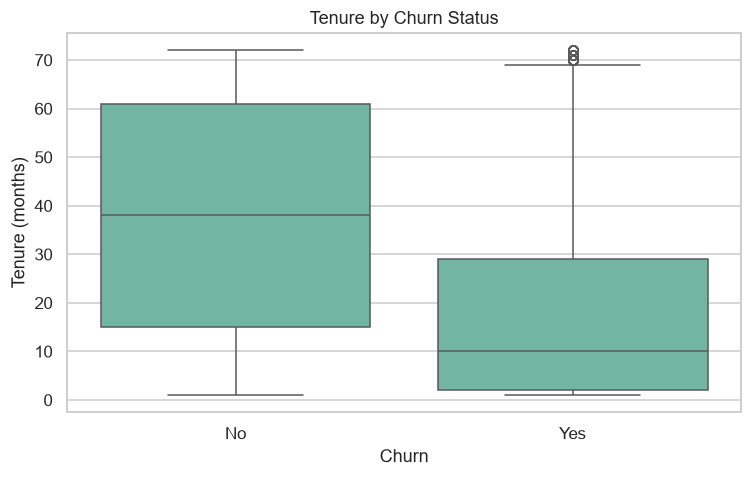

In [36]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=ax)
ax.set_title("Tenure by Churn Status")
ax.set_ylabel("Tenure (months)")

plt.tight_layout()
plt.savefig(IMAGES_PATH / "04_tenure_by_churn.png")
plt.show()


Churn is heavily concentrated among **newer customers** — the median tenure
for churned customers is much lower than for retained ones. This is exactly
what `IsNewCustomer` and `TenureGroup` are designed to make easy to filter on
in Tableau.


### Churn Rate by the Engineered Features

The features created in Section 5 aren't just for convenience — they turn
out to carry a lot of the churn signal themselves. Let's check each one.


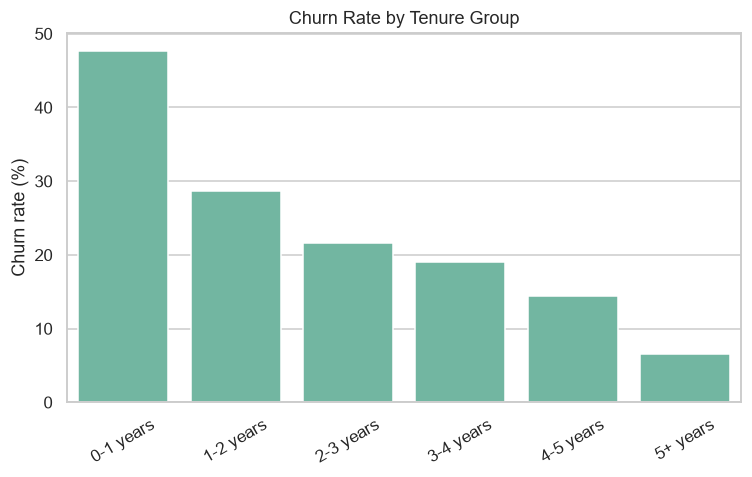

In [37]:
fig, ax = plt.subplots(figsize=(7, 4.5))

summary = churn_rate_by("TenureGroup").sort_index()
sns.barplot(x=summary.index, y=summary["churn_rate"], ax=ax)
ax.set_title("Churn Rate by Tenure Group")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(IMAGES_PATH / "05_churn_rate_by_tenure_group.png")
plt.show()


Churn risk drops sharply and steadily with tenure — customers in their
first year churn at roughly **5x the rate** of customers past year five.
This confirms `TenureGroup` is a strong, dashboard-friendly stand-in for
raw tenure.


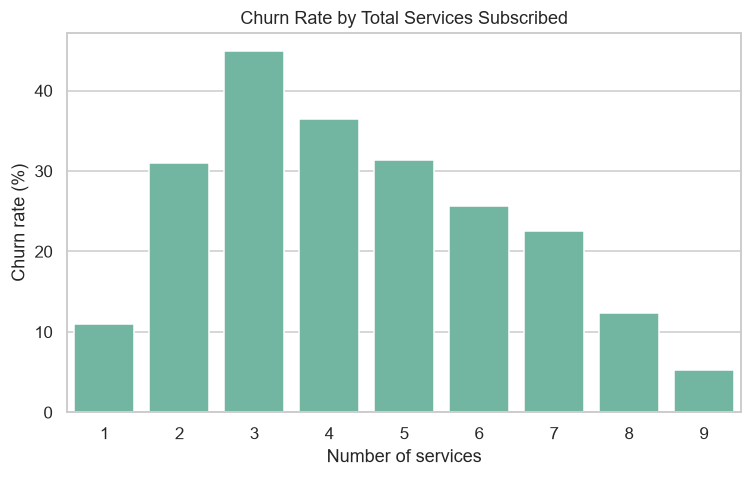

In [38]:
fig, ax = plt.subplots(figsize=(7, 4.5))

summary = churn_rate_by("TotalServices").sort_index()
sns.barplot(x=summary.index, y=summary["churn_rate"], ax=ax)
ax.set_title("Churn Rate by Total Services Subscribed")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Number of services")

plt.tight_layout()
plt.savefig(IMAGES_PATH / "06_churn_rate_by_total_services.png")
plt.show()


Customers with a moderate number of services (especially 3–4) have the highest churn rate, while customers with very few (1) or many (7+) services churn less.

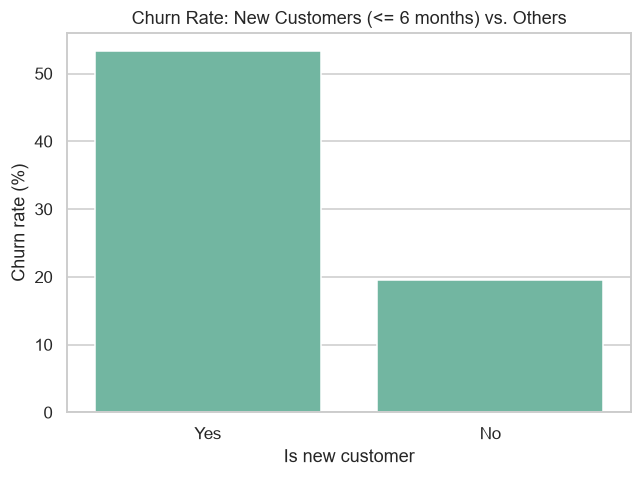

In [39]:
fig, ax = plt.subplots(figsize=(6, 4.5))

summary = churn_rate_by("IsNewCustomer")
sns.barplot(x=summary.index, y=summary["churn_rate"], ax=ax)
ax.set_title("Churn Rate: New Customers (<= 6 months) vs. Others")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Is new customer")

plt.tight_layout()
plt.savefig(IMAGES_PATH / "07_churn_rate_by_new_customer_flag.png")
plt.show()


Customers in their first six months churn at close to **3x the rate** of
everyone else — this is exactly the kind of clear, binary flag that's easy
to act on in practice (e.g. a dedicated onboarding or check-in program for
the first six months).


## 7. Export for the SQL Phase

The cleaned, feature-enriched dataset is saved as a single CSV. A plain CSV
(rather than a database file) keeps this handoff simple — the next notebook
loads it straight into SQL (via SQLite or DuckDB) for the segmentation and
revenue-at-risk analysis, and it's just as easy to load directly into Tableau.


In [40]:
df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Saved cleaned dataset to: {PROCESSED_DATA_PATH}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Saved cleaned dataset to: C:\Users\vadum\PycharmProjects\Telco Customer Churn\data\processed\telco_churn_cleaned.csv
Final shape: 7,032 rows x 27 columns


## Summary

**What was done:**
- Loaded the raw Telco Customer Churn dataset (7,043 rows, 21 columns)
- Found and fixed a hidden data quality issue: `TotalCharges` contained
  blank strings for 11 brand-new (`tenure == 0`) customers; these rows
  were removed, leaving 7,032 clean rows with zero missing values
- Standardized categorical labels (`SeniorCitizen`, `CustomerID`) for
  consistency across the dataset
- Engineered 6 new features: `TenureGroup`, `MonthlyChargesBucket`,
  `TotalServices`, `HasInternetService`, `AvgMonthlyCharges`, `IsNewCustomer`
- Exported the cleaned, feature-enriched dataset to
  `data/processed/telco_churn_cleaned.csv`

**Key findings so far:**
- Overall churn rate is roughly 1 in 4 customers
- **Contract type** is the single strongest driver — month-to-month
  customers churn at several times the rate of one- and two-year contracts
- **Fiber optic internet** and **electronic check** payments both carry
  well-above-average churn rates
- Risk is concentrated at the edges of the customer lifecycle: **new
  customers** (first 6 months) and customers with **few subscribed
  services** churn far more than tenured, well-bundled customers
- Customers who churn tend to pay **higher monthly charges** on average

**Next steps:**
The next notebook moves into SQL: loading `telco_churn_cleaned.csv` into a
database and writing queries for deeper customer segmentation,
revenue-at-risk analysis, and cohort analysis — building directly on the
features created here.
